# Calculating % of cells removed by various filters per metric

In [1]:
#load in data
import scanpy as sc
from pathlib import Path

reps = {}

raw_data_path = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\raw_adatas")

for file in raw_data_path.glob("*h5ad"):
    reps[file.stem.removesuffix('raw_adata')] = sc.read_h5ad(file) 

len(reps)

30

In [2]:
#calculate QC metrics
for adata in reps.values():
    sc.pp.calculate_qc_metrics(adata, inplace=True)

In [3]:
def rename_compartments(item):
    #remove replicate information, keep compartment:
    if 'artilage' in item:  #not sure how to be case insensitive, just removing first letter
        item = 'cartilage'
    elif 'orsal' in item:
        if 'pidermis' in item:
            item = 'dorsal_epidermis'
        elif 'pidermis' not in item:
            item = 'dorsal_dermis'
    elif 'entral' in item:
        if 'pidermis' in item:
            item = 'ventral_epidermis'
        elif 'pidermis' not in item:
            item = 'ventral_dermis'
    return item

for bdata in reps.values():
    bdata.obs['compartment'] = bdata.obs['compartment'].apply(rename_compartments)
    print(bdata.obs['compartment'].unique())

['dorsal_epidermis', 'dorsal_dermis', 'cartilage', 'ventral_dermis', 'ventral_epidermis']
Categories (5, object): ['cartilage', 'dorsal_dermis', 'dorsal_epidermis', 'ventral_dermis', 'ventral_epidermis']
['dorsal_epidermis', 'dorsal_dermis', 'cartilage', 'ventral_dermis', 'ventral_epidermis']
Categories (5, object): ['cartilage', 'dorsal_epidermis', 'dorsal_dermis', 'ventral_epidermis', 'ventral_dermis']
['ventral_epidermis', 'ventral_dermis', 'cartilage', 'dorsal_dermis', 'dorsal_epidermis']
Categories (5, object): ['cartilage', 'dorsal_dermis', 'ventral_dermis', 'dorsal_epidermis', 'ventral_epidermis']
['ventral_epidermis', 'ventral_dermis', 'cartilage', 'dorsal_dermis', 'dorsal_epidermis']
Categories (5, object): ['cartilage', 'dorsal_epidermis', 'dorsal_dermis', 'ventral_epidermis', 'ventral_dermis']
['ventral_epidermis', 'ventral_dermis', 'cartilage', 'dorsal_dermis', 'dorsal_epidermis']
Categories (5, object): ['cartilage', 'dorsal_dermis', 'dorsal_epidermis', 'ventral_dermis', '

In [4]:
#filter objects by 1% smallest
import numpy as np
import pandas as pd

#size based
for name, adata in reps.items():
    total_original_cells = len(adata) 

    percentile_threshold = 1 #change this to filter out more or less cells
    size_threshold = np.percentile(adata.obs['cell_area'], percentile_threshold) 

    size_mask = adata.obs['cell_area'] > size_threshold 
    num_removed_size = (~size_mask).sum() #no. cells removed

    adata = adata[size_mask].copy()

    print(f'Removed {num_removed_size/total_original_cells *100:.2f}% of cells based on size requirements')

Removed 1.03% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.01% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.02% of cells based on size requirements
Removed 1.01% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.01% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.02% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.01% of cells based on size requirements
Removed 1.01% of cells based on size requirements
Removed 1.02% of cells based on size requirements


In [5]:
test = reps['Ctrl_F1'].copy()
adata.obs.value_counts('compartment')

compartment
ventral_epidermis    3342
dorsal_dermis        3116
ventral_dermis       2918
dorsal_epidermis     2777
cartilage             834
Name: count, dtype: int64

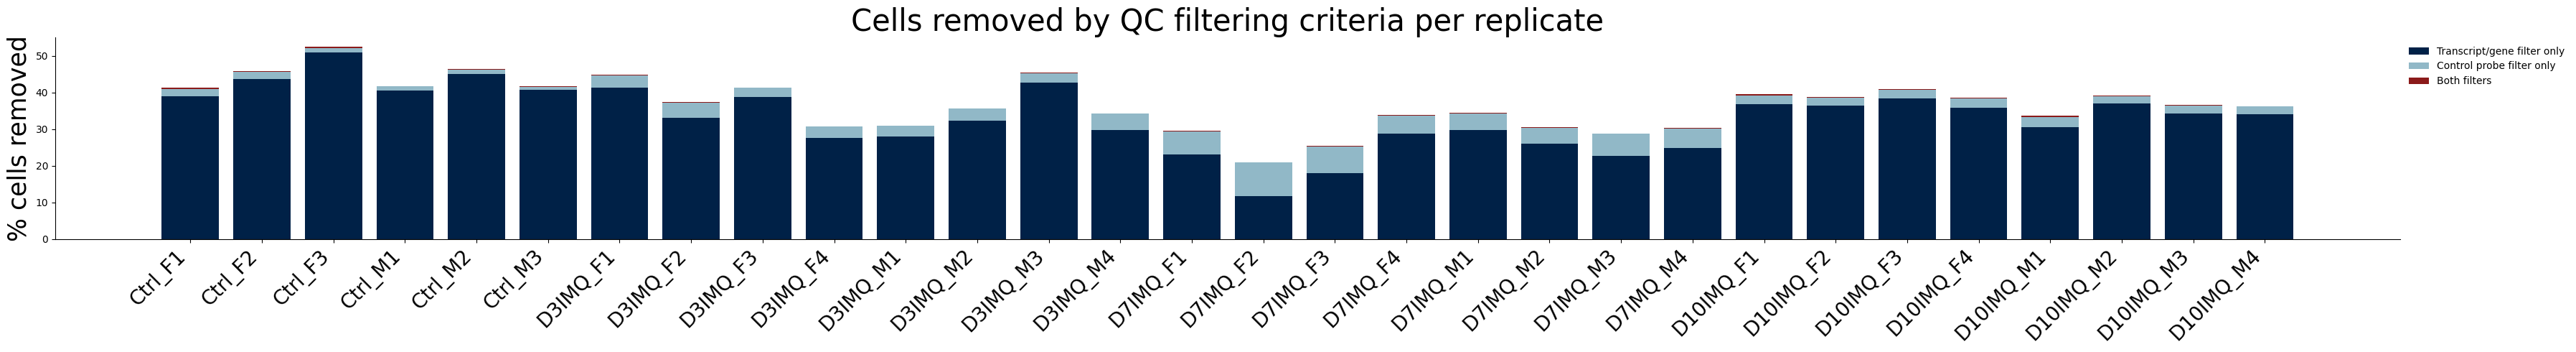

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import re

rep_data = {}
for name, adata in reps.items():
    total = len(adata)

    t_mask = (
        (adata.obs['transcript_counts'] < 10) | (adata.obs['n_genes_by_counts'] < 10)
    ) & (
        (adata.obs['control_probe_counts'] == 0) &
        (adata.obs['genomic_control_counts'] == 0) &
        (adata.obs['control_codeword_counts'] == 0) &
        (adata.obs['unassigned_codeword_counts'] == 0)
    )

    c_mask = (
        (adata.obs['transcript_counts'] > 10) & (adata.obs['n_genes_by_counts'] > 10)
    ) & (
        (adata.obs['control_probe_counts'] > 0) |
        (adata.obs['genomic_control_counts'] > 0) |
        (adata.obs['control_codeword_counts'] > 0) |
        (adata.obs['unassigned_codeword_counts'] > 0)
    )

    b_mask = (
        (adata.obs['transcript_counts'] < 10) | (adata.obs['n_genes_by_counts'] < 10)
    ) & (
        (adata.obs['control_probe_counts'] > 0) |
        (adata.obs['genomic_control_counts'] > 0) |
        (adata.obs['control_codeword_counts'] > 0) |
        (adata.obs['unassigned_codeword_counts'] > 0)
    )

    rep_data[name] = {
        'transcript': t_mask.sum() / total * 100,
        'control':    c_mask.sum() / total * 100,
        'both':       b_mask.sum() / total * 100,
    }

# --- plot ---
def sort_key(name):
    if 'Ctrl' in name:
        return (0, name)
    match = re.search(r'D(\d+)', name)
    return (int(match.group(1)), name) if match else (999, name)

labels = sorted(rep_data.keys(), key=sort_key)
transcript  = [rep_data[k]['transcript'] for k in labels]
control     = [rep_data[k]['control']    for k in labels]
both        = [rep_data[k]['both']       for k in labels]

oxford_blue   = '#002147'
dark_red      = '#8B1A1A'
cambridge_blue = '#91B8C7'

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(max(5, len(labels) * 1.2), 5))

b1 = ax.bar(x, transcript, color=oxford_blue,    label='Transcript/gene filter only')
b2 = ax.bar(x, control,    color=cambridge_blue,        label='Control probe filter only', bottom=transcript)
b3 = ax.bar(x, both,       color=dark_red,  label='Both filters',
            bottom=[t + c for t, c in zip(transcript, control)])

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize = 20)
ax.set_ylabel('% cells removed', fontsize = 25)
ax.set_title('Cells removed by QC filtering criteria per replicate', fontsize = 30)
ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig
plt.show()

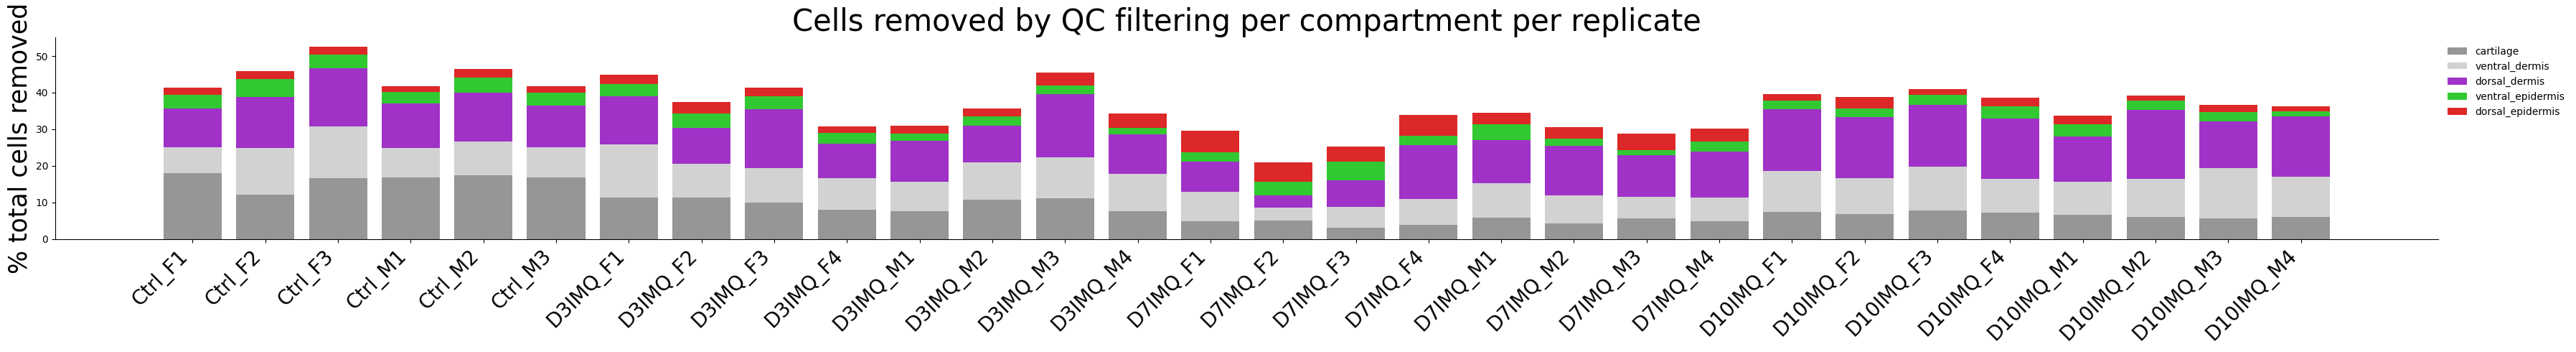

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import re

compartment_order = ['cartilage', 'ventral_dermis', 'dorsal_dermis','ventral_epidermis', 'dorsal_epidermis']
compartment_colors = ["#969696", '#D2D2D2', '#A032C8', '#32C832', '#DC2828']  

rep_compartment_data = {}
for name, adata in reps.items():
    total = len(adata)

    removed_mask = (
        (adata.obs['transcript_counts'] < 10) | (adata.obs['n_genes_by_counts'] < 10) |
        (adata.obs['control_probe_counts'] > 0) |
        (adata.obs['genomic_control_counts'] > 0) |
        (adata.obs['control_codeword_counts'] > 0) |
        (adata.obs['unassigned_codeword_counts'] > 0)
    )

    removed_obs = adata.obs[removed_mask]

    rep_compartment_data[name] = {}
    for comp in compartment_order:
        n_removed = (removed_obs['compartment'] == comp).sum()
        rep_compartment_data[name][comp] = n_removed / total * 100

# --- plot ---
def sort_key(name):
    if 'Ctrl' in name:
        return (0, name)
    match = re.search(r'D(\d+)', name)
    return (int(match.group(1)), name) if match else (999, name)

labels = sorted(rep_compartment_data.keys(), key=sort_key)
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(max(5, len(labels) * 1.2), 5))

bottoms = np.zeros(len(labels))
for comp, color in zip(compartment_order, compartment_colors):
    vals = np.array([rep_compartment_data[k][comp] for k in labels])
    ax.bar(x, vals, bottom=bottoms, color=color, label=comp, width = 0.8)
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
ax.set_ylabel('% total cells removed', fontsize=25)
ax.set_title('Cells removed by QC filtering per compartment per replicate', fontsize=30)
ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

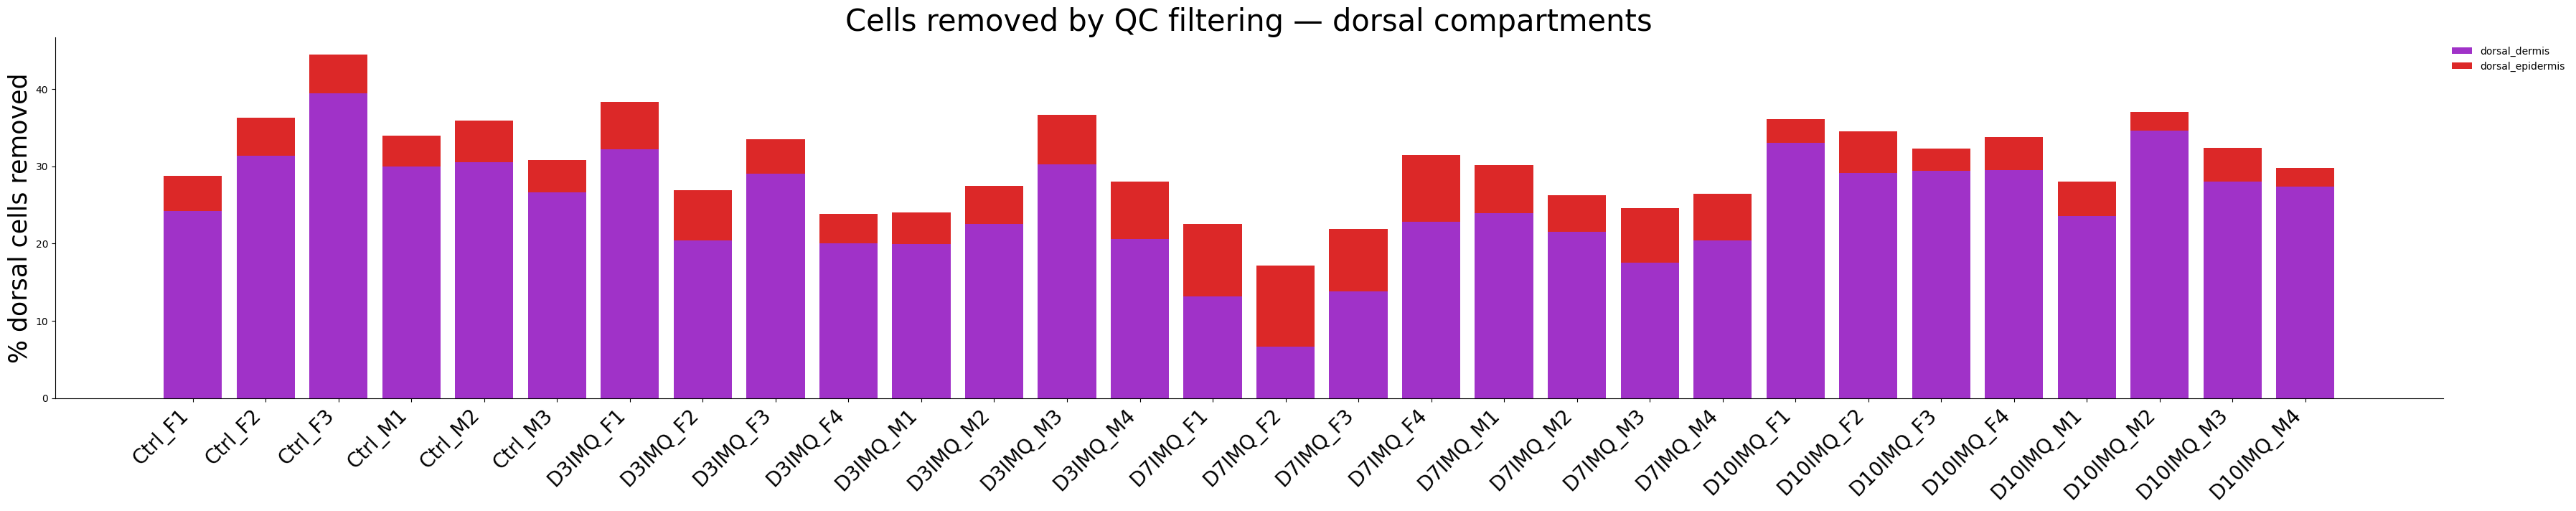

In [8]:
#plotting QC for the dorsal side only

import matplotlib.pyplot as plt
import numpy as np
import re

compartment_order = ['cartilage', 'ventral_dermis', 'dorsal_dermis','ventral_epidermis', 'dorsal_epidermis']
compartment_colors = ["#969696", '#D2D2D2', '#A032C8', '#32C832', '#DC2828']  
dorsal_order = ['dorsal_dermis', 'dorsal_epidermis']
dorsal_colors = ['#A032C8', '#DC2828']

rep_compartment_data = {}
for name, adata in reps.items():
    dorsal_mask = adata.obs['compartment'].isin(dorsal_order)
    dorsal_total = dorsal_mask.sum()

    removed_mask = (
        (adata.obs['transcript_counts'] < 10) | (adata.obs['n_genes_by_counts'] < 10) |
        (adata.obs['control_probe_counts'] > 0) |
        (adata.obs['genomic_control_counts'] > 0) |
        (adata.obs['control_codeword_counts'] > 0) |
        (adata.obs['unassigned_codeword_counts'] > 0)
    )

    removed_obs = adata.obs[removed_mask & dorsal_mask]

    rep_compartment_data[name] = {}
    for comp in dorsal_order:
        n_removed = (removed_obs['compartment'] == comp).sum()
        rep_compartment_data[name][comp] = n_removed / dorsal_total * 100

# --- plot ---
def sort_key(name):
    if 'Ctrl' in name:
        return (0, name)
    match = re.search(r'D(\d+)', name)
    return (int(match.group(1)), name) if match else (999, name)

labels = sorted(rep_compartment_data.keys(), key=sort_key)
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(max(5, len(labels) * 1.2), 8))

bottoms = np.zeros(len(labels))
for comp, color in zip(dorsal_order, dorsal_colors):
    vals = np.array([rep_compartment_data[k][comp] for k in labels])
    ax.bar(x, vals, bottom=bottoms, color=color, label=comp, width=0.8)
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
ax.set_ylabel('% dorsal cells removed', fontsize=25)
ax.set_title('Cells removed by QC filtering — dorsal compartments', fontsize=30)
ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

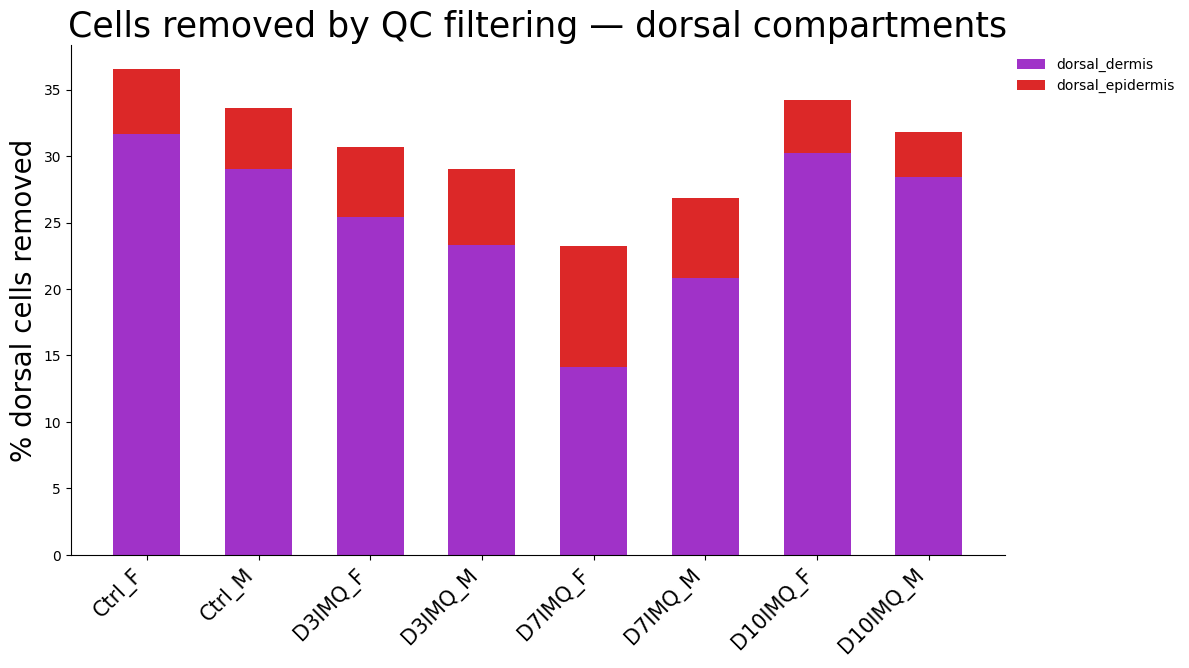

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import defaultdict

compartment_order = ['cartilage', 'ventral_dermis', 'dorsal_dermis','ventral_epidermis', 'dorsal_epidermis']
compartment_colors = ["#969696", '#D2D2D2', '#A032C8', '#32C832', '#DC2828']  
dorsal_order = ['dorsal_dermis', 'dorsal_epidermis']
dorsal_colors = ['#A032C8', '#DC2828']

rep_compartment_data = {}
for name, adata in reps.items():
    dorsal_mask = adata.obs['compartment'].isin(dorsal_order)
    dorsal_total = dorsal_mask.sum()

    removed_mask = (
        (adata.obs['transcript_counts'] < 10) | (adata.obs['n_genes_by_counts'] < 10) |
        (adata.obs['control_probe_counts'] > 0) |
        (adata.obs['genomic_control_counts'] > 0) |
        (adata.obs['control_codeword_counts'] > 0) |
        (adata.obs['unassigned_codeword_counts'] > 0)
    )

    removed_obs = adata.obs[removed_mask & dorsal_mask]

    rep_compartment_data[name] = {}
    for comp in dorsal_order:
        n_removed = (removed_obs['compartment'] == comp).sum()
        # Avoid division by zero if a replicate has no dorsal cells
        rep_compartment_data[name][comp] = (n_removed / dorsal_total * 100) if dorsal_total > 0 else 0

# --- Aggregate replicate data by condition ---
condition_data = defaultdict(lambda: defaultdict(list))

for rep_name, comps in rep_compartment_data.items():
    # Extract condition name by removing trailing digits and an optional preceding underscore
    # e.g., 'Ctrl_F1' -> 'Ctrl_F' or 'D3IMQ_M1' -> 'D3IMQ_M'
    condition = re.sub(r'_?\d+$', '', rep_name)
    
    for comp, val in comps.items():
        condition_data[condition][comp].append(val)

# Compute the mean percentage for each condition
avg_condition_data = {}
for condition, comps in condition_data.items():
    avg_condition_data[condition] = {}
    for comp, vals in comps.items():
        avg_condition_data[condition][comp] = np.mean(vals)

# --- plot ---
def sort_key(name):
    if 'Ctrl' in name:
        return (0, name)
    match = re.search(r'D(\d+)', name)
    return (int(match.group(1)), name) if match else (999, name)

# Sort based on condition keys instead of individual replicates
labels = sorted(avg_condition_data.keys(), key=sort_key)
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(max(5, len(labels) * 1.5), 8))

bottoms = np.zeros(len(labels))
for comp, color in zip(dorsal_order, dorsal_colors):
    vals = np.array([avg_condition_data[k][comp] for k in labels])
    ax.bar(x, vals, bottom=bottoms, color=color, label=comp, width=0.6)
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=15)
ax.set_ylabel('% dorsal cells removed', fontsize=20)
ax.set_title('Cells removed by QC filtering — dorsal compartments', fontsize=25)
ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.savefig(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\QC_figures\QC_per_condition_dorsal.png", dpi = 500)

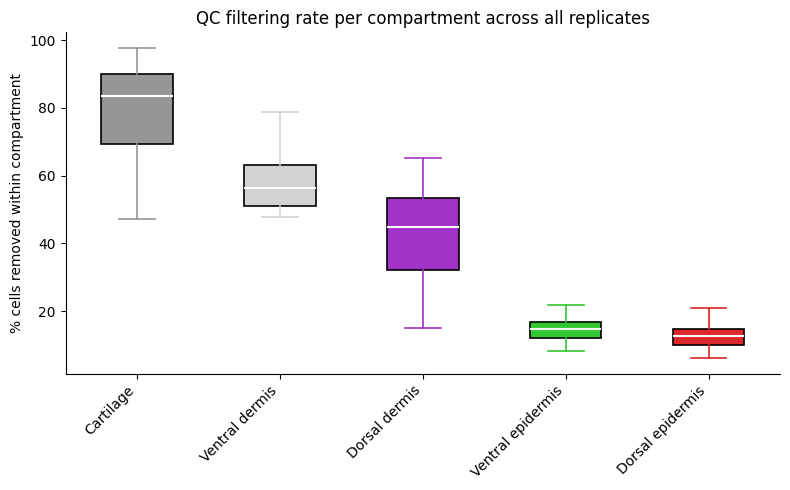

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

compartment_order = ['cartilage', 'ventral_dermis', 'dorsal_dermis','ventral_epidermis', 'dorsal_epidermis']
compartment_colors = ["#969696", '#D2D2D2', '#A032C8', '#32C832', '#DC2828']  

comp_data = {comp: [] for comp in compartment_order}

for name, adata in reps.items():
    removed_mask = (
        (adata.obs['transcript_counts'] < 10) | (adata.obs['n_genes_by_counts'] < 10) |
        (adata.obs['control_probe_counts'] > 0) |
        (adata.obs['genomic_control_counts'] > 0) |
        (adata.obs['control_codeword_counts'] > 0) |
        (adata.obs['unassigned_codeword_counts'] > 0)
    )
    removed_obs = adata.obs[removed_mask]

    for comp in compartment_order:
        comp_total = (adata.obs['compartment'] == comp).sum()
        n_removed = (removed_obs['compartment'] == comp).sum()
        comp_data[comp].append(n_removed / comp_total * 100)

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 5))

data = [comp_data[comp] for comp in compartment_order]

bp = ax.boxplot(data, patch_artist=True,
                medianprops=dict(linewidth=1.5),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                boxprops=dict(linewidth=1.2),
                showfliers=False)
for patch, color in zip(bp['boxes'], compartment_colors):
    patch.set_facecolor(color)

for i, color in enumerate(compartment_colors):
    for element in ['whiskers', 'caps']:
        bp[element][i*2].set_color(color)
        bp[element][i*2+1].set_color(color)
    bp['medians'][i].set_color('white')

# for i, (comp, color, pos) in enumerate(zip(compartment_order, compartment_colors, range(1, len(compartment_order) + 1))):
#     for element in ['medians', 'whiskers', 'caps', 'boxes']:
#         for item in bp[element][i*2:i*2+2] if element != 'medians' else [bp[element][i]]:
#             item.set_color(color)

#     jitter = np.random.uniform(-0.1, 0.1, size=len(comp_data[comp]))
#     ax.scatter(pos + jitter, comp_data[comp],
#                facecolors='#0D0C0C', edgecolors='#0D0C0C', alpha=1, s=25, zorder=3)

ax.set_xticks(range(1, len(compartment_order) + 1))

label_names = ['Cartilage', 'Ventral dermis', 'Dorsal dermis', 'Ventral epidermis', 'Dorsal epidermis']

ax.set_xticklabels(label_names, rotation=45, ha='right')
ax.set_ylabel('% cells removed within compartment')
ax.set_title('QC filtering rate per compartment across all replicates')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\QC_figures\QC_per_compartment.png", dpi = 500, bbox_inches = 'tight')
plt.show()

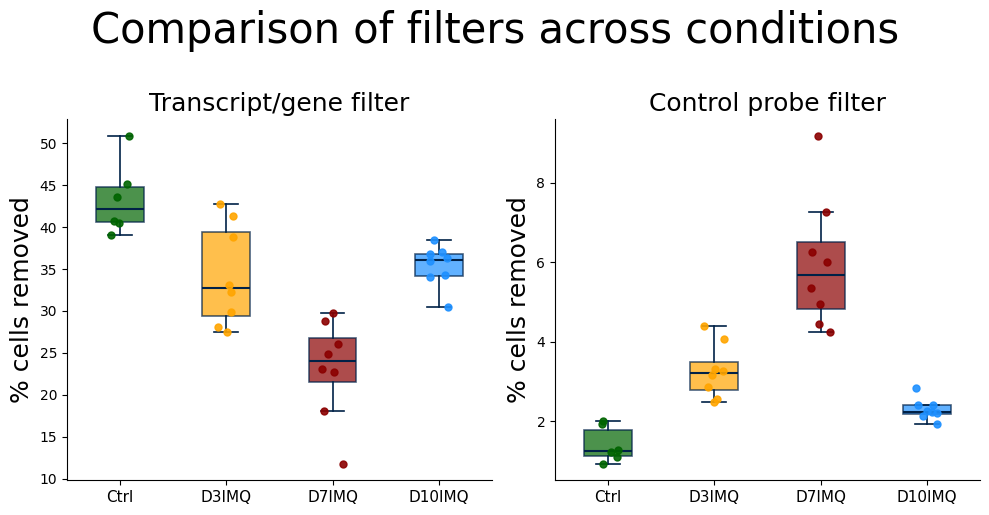

In [18]:
import re
import matplotlib.pyplot as plt
import numpy as np

# --- organise data by condition ---
conditions_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

# Dictionary defining the specified hex colors for each condition
condition_colors = {
    'Ctrl': '#006400',       # Dark Green
    'D3IMQ': '#FFA500',      # Orange
    'D7IMQ': '#8B0000',      # Dark Red
    'D10IMQ': '#1E90FF'      # Dodger Blue
}

grouped = {cond: {'transcript': [], 'control': []} for cond in conditions_order}

for name, vals in rep_data.items():
    for cond in conditions_order:
        if cond in name:
            grouped[cond]['transcript'].append(vals['transcript'])
            grouped[cond]['control'].append(vals['control'])
            break

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

titles  = ['Transcript/gene filter', 'Control probe filter']
metrics = ['transcript', 'control']

for ax, metric, title in zip(axes, metrics, titles):
    data = [grouped[cond][metric] for cond in conditions_order]

    # Set patch_artist=True to enable filling the boxes with color
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color='#002147', linewidth=1.5),
                    whiskerprops=dict(color='#002147', linewidth=1.2),
                    capprops=dict(color='#002147', linewidth=1.2),
                    boxprops=dict(color='#002147', linewidth=1.2),
                    showfliers=False)

    # Apply condition-wise coloring to boxes and scatter points
    for i, (cond, patch) in enumerate(zip(conditions_order, bp['boxes'])):
        color = condition_colors[cond]
        
        # Color the inside of the box (alpha adds transparency so lines stay clear)
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        
        # Color the individual jittered data points
        cond_data = data[i]
        pos = i + 1
        jitter = np.random.uniform(-0.1, 0.1, size=len(cond_data))
        ax.scatter(pos + jitter, cond_data,
                   facecolors=color, edgecolors=color, alpha=0.9, s=25, zorder=3)

    ax.set_xticks(range(1, len(conditions_order) + 1))
    ax.set_xticklabels(conditions_order, fontsize = 11)
    ax.set_ylabel('% cells removed', fontsize = 18)
    ax.set_title(title, fontsize = 18)
    ax.spines[['top', 'right']].set_visible(False)


fig.suptitle('Comparison of filters across conditions', fontsize=30, y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\QC_figures\QC_filter_comparison.png", dpi = 500, bbox_inches = 'tight')
plt.show()


# Transcript Density across compartments

In [16]:
#load in data
import scanpy as sc
from pathlib import Path

reps = {}

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")


In [17]:
adata

AnnData object with n_obs × n_vars = 193025 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'shape_index', 'solidity', 'replicate', 'condition', 'batch_key', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden', 'highlight', 'leiden_0.5', 'leiden_0.65', 'leiden_0.75', 'leiden_0.85', 'leiden_1.0', 'mac_subcluster', '3_subcluster', 'celltype_assignments', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter', 'sex'
    var: 'gene_ids', 'feature_types', 'genom

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_compartment_densities(
    adata,
    batch_key="batch_key",
    count_key="transcript_counts",
    area_key="region_surface_areas_um2",
    compartments=None,
    colors=None,
    scale=1.0,   # use 1e6 for "per mm^2" because 1 mm^2 = 1e6 µm^2
    figsize=(8, 5),
    show_points=True,
):
    # Surface areas stored in adata.uns
    area_dict = adata.uns[area_key]

    # Pick compartment order from the first replicate unless given explicitly
    if compartments is None:
        first_rep = next(iter(area_dict))
        compartments = list(area_dict[first_rep].keys())

    # Sum transcripts per replicate
    rep_totals = (
        adata.obs[[batch_key, count_key]]
        .groupby(batch_key, observed=True)[count_key]
        .sum()
    )

    rows = []
    for rep, comp_areas in area_dict.items():
        if rep not in rep_totals.index:
            continue

        total_transcripts = rep_totals.loc[rep]

        for comp in compartments:
            area = comp_areas.get(comp, np.nan)
            if pd.isna(area) or area <= 0:
                continue

            density = (total_transcripts / area) * scale
            rows.append(
                {
                    "replicate": rep,
                    "compartment": comp,
                    "density": density,
                }
            )

    df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=figsize)

    data = [df.loc[df["compartment"] == comp, "density"].dropna().values
            for comp in compartments]

    bp = ax.boxplot(
        data,
        labels=[x.replace("_", " ") for x in compartments],
        patch_artist=True,
        showfliers=False,
    )

    ax.tick_params(axis="x", labelsize=20)

    # Handle colours
    if colors is None:
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    if isinstance(colors, dict):
        facecolors = [colors.get(comp, "lightgrey") for comp in compartments]
    else:
        facecolors = [colors[i % len(colors)] for i in range(len(compartments))]

    for patch, c in zip(bp["boxes"], facecolors):
        patch.set_facecolor(c)

    if show_points:
        for i, comp in enumerate(compartments, start=1):
            y = df.loc[df["compartment"] == comp, "density"].values
            x = np.random.normal(i, 0.05, size=len(y))
            ax.scatter(x, y, s=10, alpha=0.4, color="black", zorder=3)

    ax.set_ylabel(f"Transcript density /mm²)", fontsize = 20)
    ax.tick_params(axis="x", rotation=45)

    ax.margins(x=0.05)
    plt.tight_layout()
    plt.savefig(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\QC_figures\density_quant.png", bbox_inches = 'tight', dpi = 500)

    return fig, ax, df

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_25020\1563251278.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


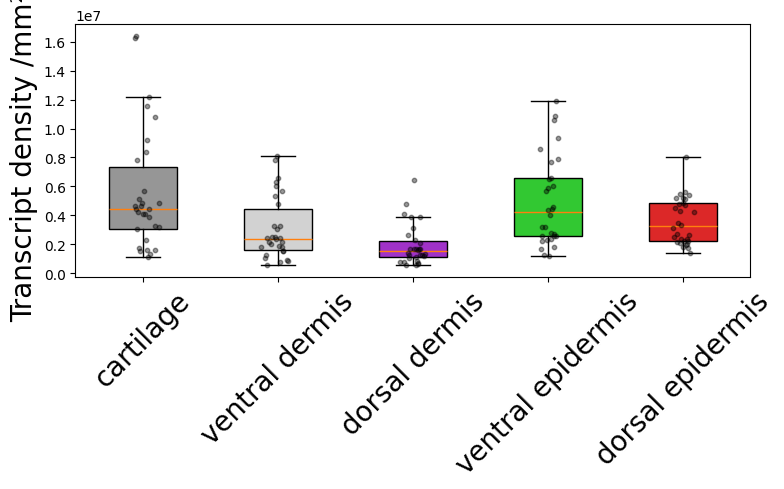

In [45]:
comp_colors = ["#969696", '#D2D2D2', '#A032C8', '#32C832', '#DC2828']

compartment_order = ['cartilage', 'ventral_dermis', 'dorsal_dermis','ventral_epidermis', 'dorsal_epidermis']
# compartment_colors = ["#969696", '#D2D2D2', '#A032C8', '#32C832', '#DC2828']  

fig, ax, density_df = plot_compartment_densities(
    adata,
    compartments = compartment_order,
    colors=comp_colors,
    scale=1e6,   # per mm^2 #change title if you change this
)
plt.show()